In [1]:
# Array and data functions
from glob import glob
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ParamSampler
from MEDUSSA.utils import Relabeler,BorderRemoval,IntersectionKDE

from skimage import io

import warnings
warnings.filterwarnings('ignore')

In [3]:
manual_masks = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig4/Test_Masks/0*.tif'))
omnipose_masks = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig4/FMSeg/0*'))

print(len(manual_masks))

assert len(manual_masks) == len(omnipose_masks)

manual_masks = [io.imread(mask) for mask in manual_masks]

# Remove border segmentations
omnipose_masks = [BorderRemoval(io.imread(mask)) for mask in omnipose_masks]


16


In [14]:
manual_cells = SizeDataFrame(manual_masks,from_files=False)
manual_cells.insert(0,'Method','Manual')
manual_cells = manual_cells.dropna()

relabeled_masks = [Relabeler(manual,omni) for manual,omni in zip(manual_masks,omnipose_masks)]

omnipose_cells = SizeDataFrame(relabeled_masks,from_files=False)
omnipose_cells.insert(0,'Method','Automatic')
omnipose_cells = omnipose_cells[omnipose_cells['Width'] > 0.3]
omnipose_cells = omnipose_cells.dropna()

In [15]:
df_posteriors = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Figures/FigureS4/posterior_segmentation_measurements.csv')

metrics = ['Width','Length','SurfaceArea','Volume']

sampled_df_automatic = ParamSampler(omnipose_cells,df_posteriors,columns=['Method'],metrics=metrics)

In [23]:
manual_cells.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/Fig4c_manual.csv')
omnipose_cells.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/Fig4c_automatic.csv')
sampled_df_automatic.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/Fig4c_automatic_transformed.csv')


In [ ]:
manual_cells.to_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/Fig4c_manual.csv')
omnipose_cells.to_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/Fig4c_automatic.csv')
sampled_df_automatic.to_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/Fig4c_automatic_transformed.csv')

In [16]:
w0 = np.array(manual_cells['Width'])
w1 = np.array(omnipose_cells['Width'])
w2 = np.array(sampled_df_automatic['Width_mu'])

#w01,kde_w0,kde_w1,inters_w01 = IntersectionKDE(w0,w1)
#w02,kde_w0,kde_w2,inters_w02 = IntersectionKDE(w0,w2)


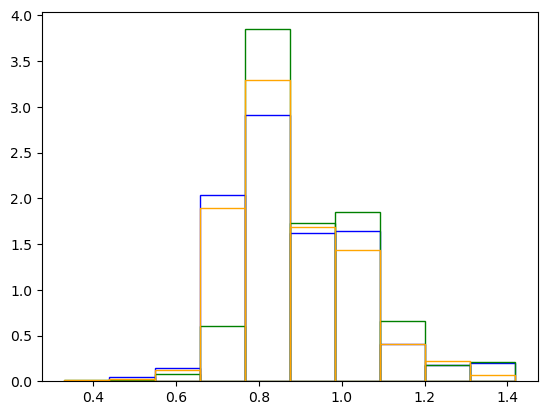

In [17]:
## Reviewer suggestion, compute KL divergence
def kl_divergence(a, b):
    return sum(a[i] * np.log(a[i]/b[i]) for i in range(len(a)))

### Obtain maximum and minimum values for calculating the PDFs
max_w = np.max(np.concat([w0,w1,w2]))
min_w = np.min(np.concat([w0,w1,w2]))

### Obtain PDF of each method 
w0_pdf = plt.hist(w0,range=[min_w,max_w],density=True,facecolor='none',edgecolor='blue')
w1_pdf = plt.hist(w1,range=[min_w,max_w],density=True,facecolor='none',edgecolor='green')
w2_pdf = plt.hist(w2,range=[min_w,max_w],density=True,facecolor='none',edgecolor='orange')

In [18]:
### Compute KL divergence of the automatic widths (pre- and post-transformation) against the ground-truth

w0_w1 = kl_divergence(w0_pdf[0]+1**(-5),w1_pdf[0]+1**(-5))
w0_w2 = kl_divergence(w0_pdf[0]+1**(-5),w2_pdf[0]+1**(-5))

print(f'KL divergence between automatic and ground-truth widths = {w0_w1:.3f}')
print(f'KL divergence between automatic and transformed widths = {w0_w2:.3f}')

KL divergence between automatic and ground-truth widths = 0.629
KL divergence between automatic and transformed widths = 0.040


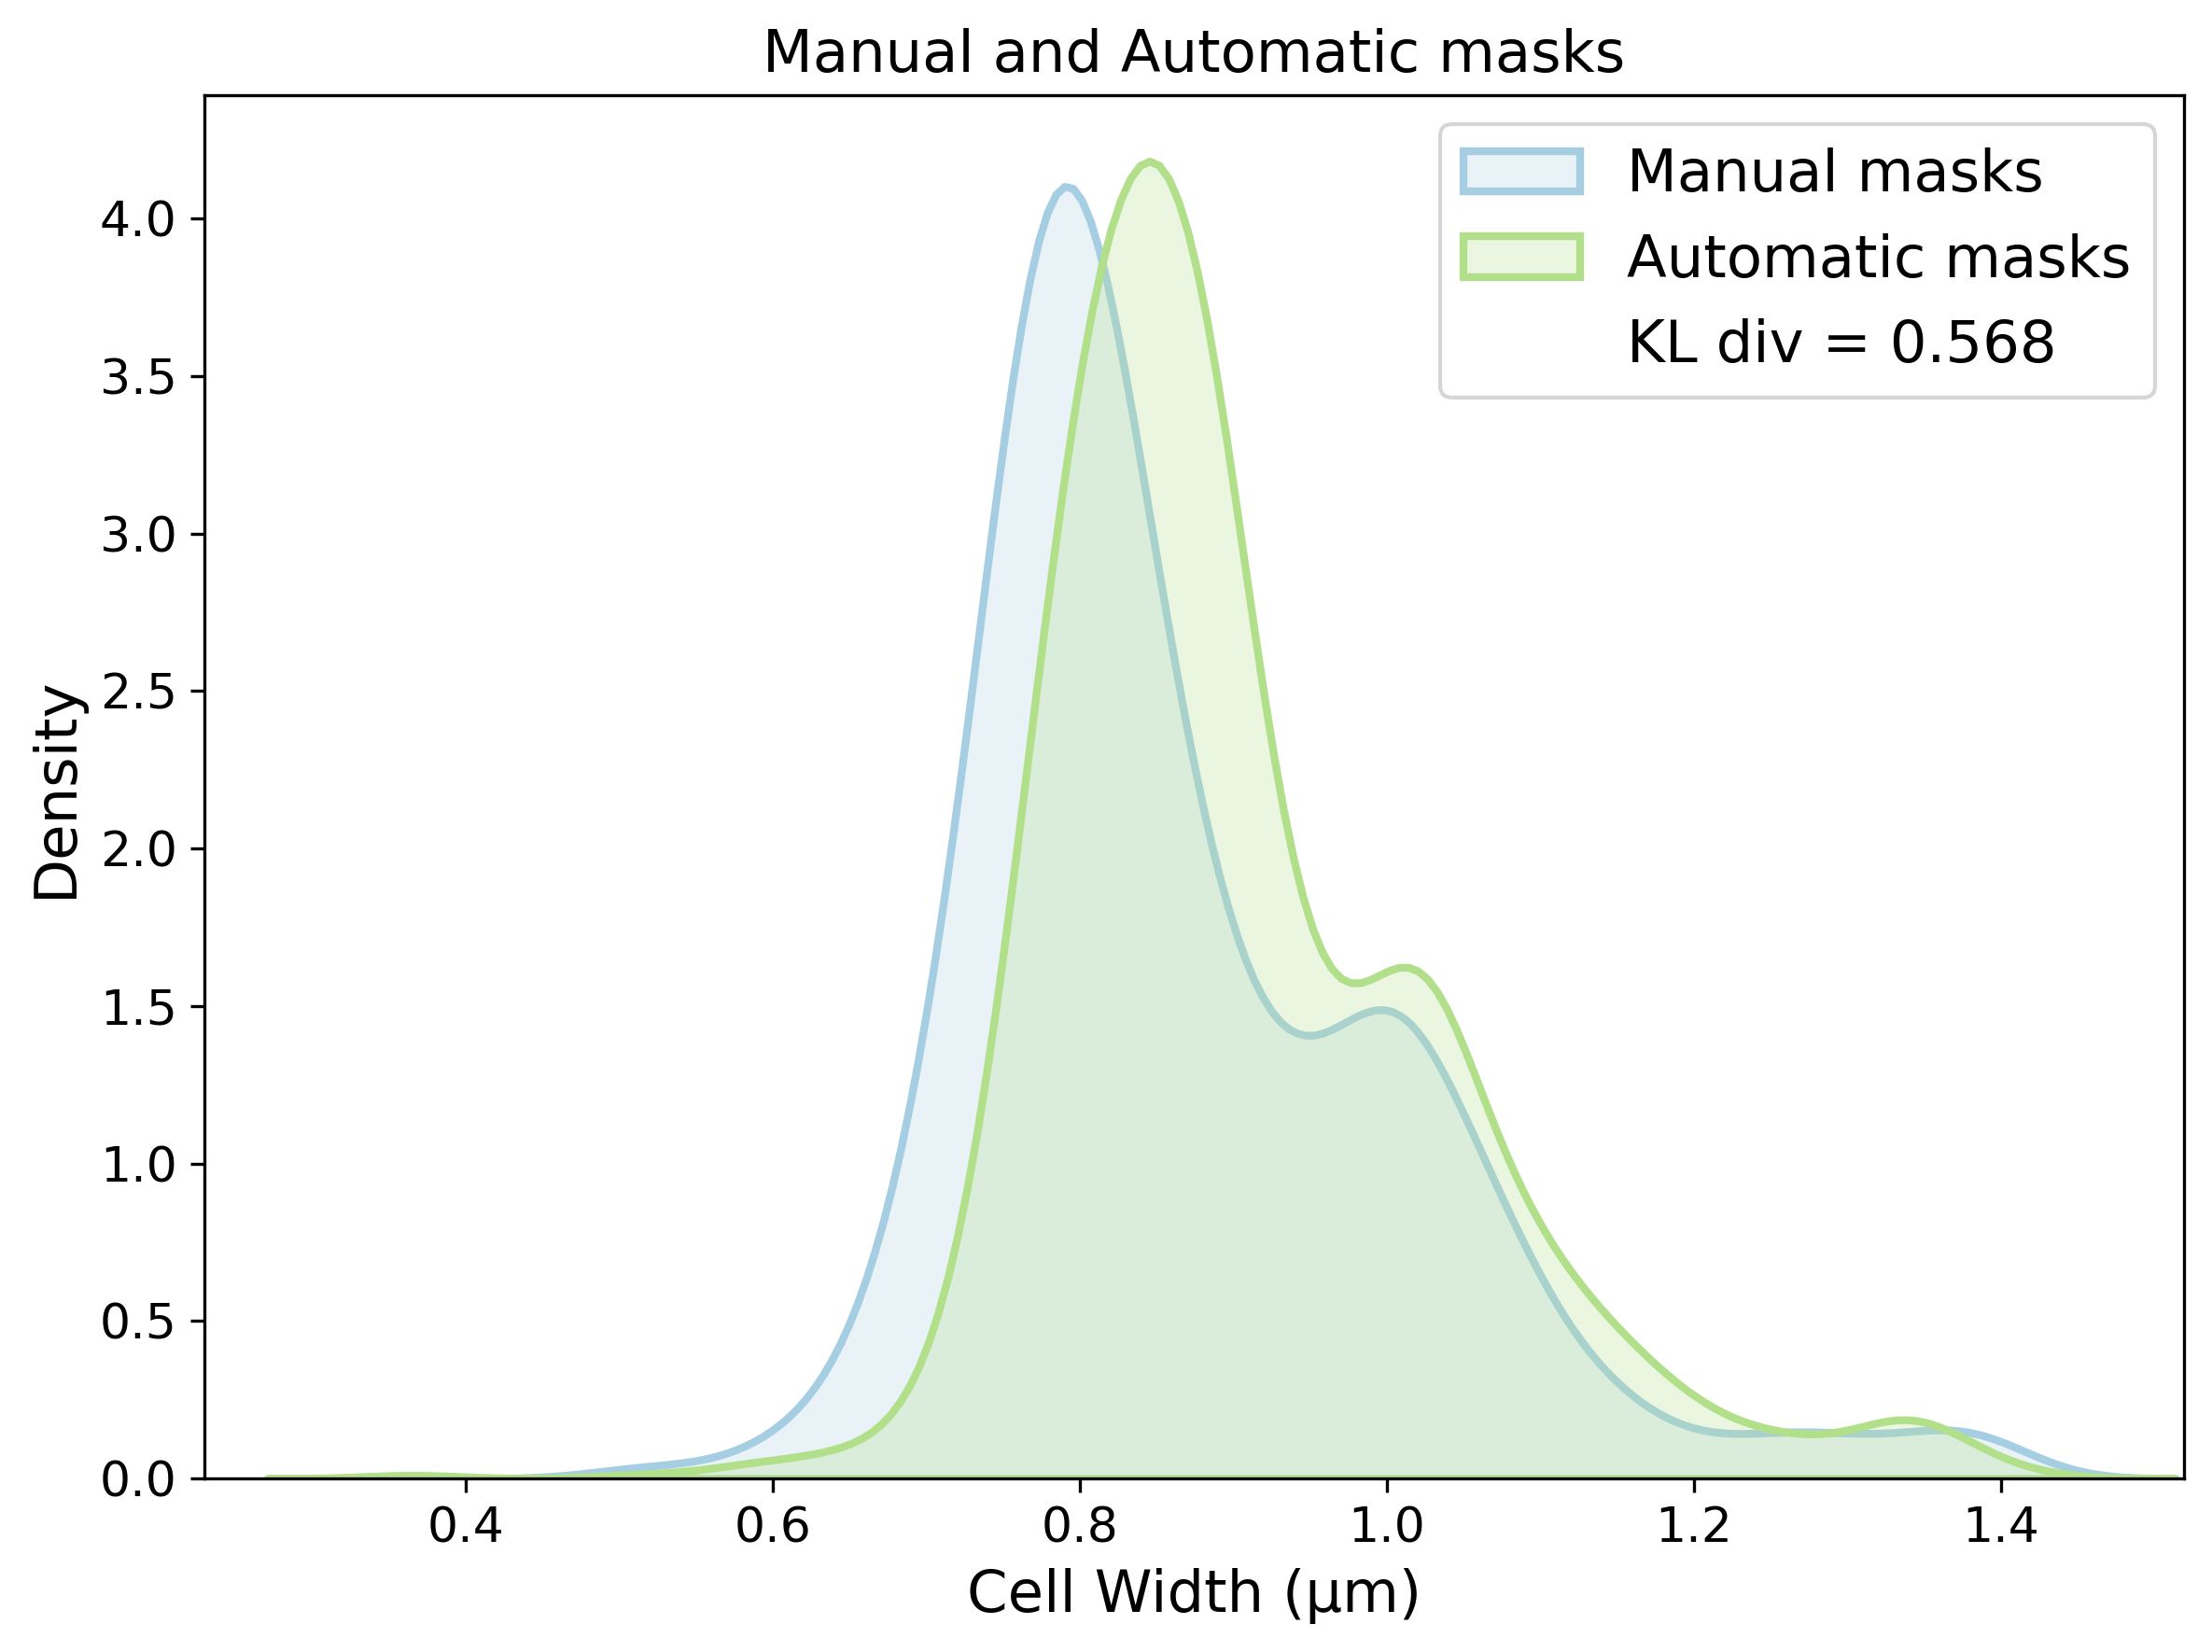

In [121]:
### We'll recreate the panels on the figure without the cross-hatch pattern and just providing the KL divergence values

fig,ax = plt.subplots(dpi=300,figsize=(8,6))

sns.kdeplot(w0,fill=True, ax=ax, color='#a6cee3', label='Manual masks', linewidth=2)
sns.kdeplot(w1,fill=True, ax=ax, color='#b2df8a', label='Automatic masks', linewidth=2)

ax.plot(0, 0, color='none', label=f'KL div = {w0_w1:.3f}')

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles, labels,fontsize=15)
ax.set_xlabel('Cell Width (µm)',fontsize=15)
ax.set_ylabel('Density',fontsize=15)
ax.set_xlim(min_w-0.1,max_w+0.1)
ax.set_title(f'Manual and Automatic masks',fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(),fontsize=12.5) 
ax.set_yticklabels(ax.get_yticklabels(),fontsize=12.5) 

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig4/Intersection_KDE_MA_revised.png')

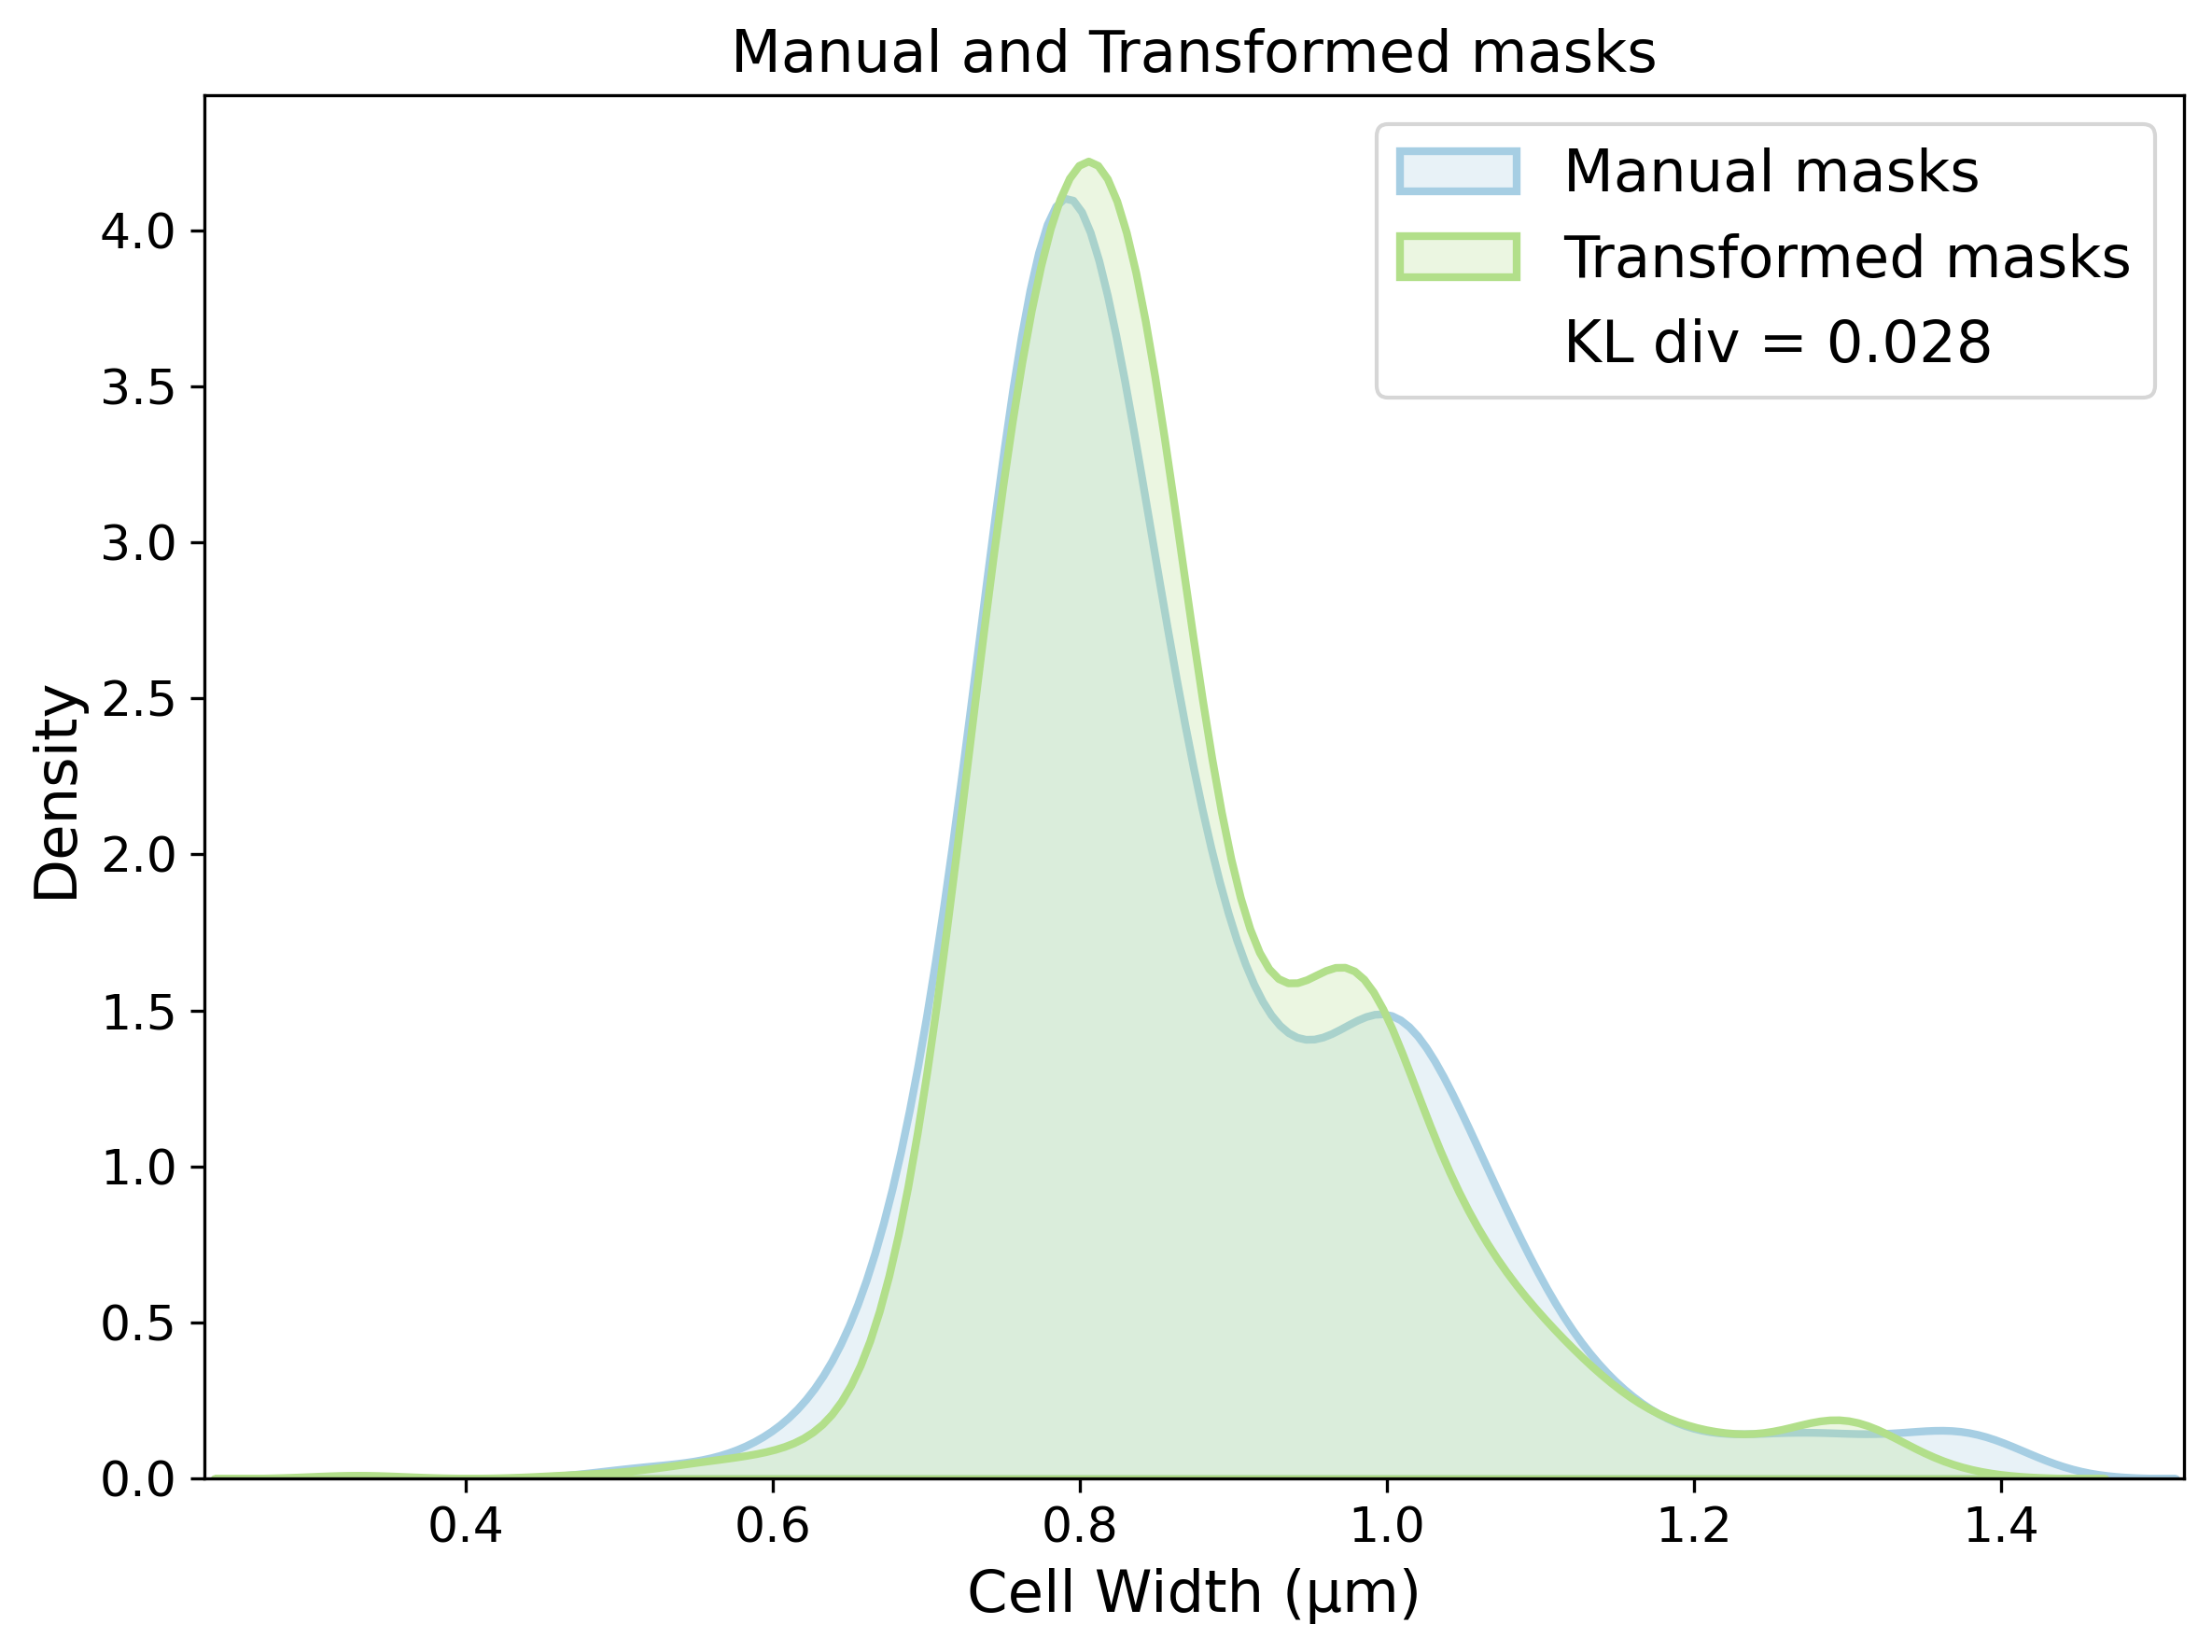

In [120]:
### We'll recreate the panels on the figure without the cross-hatch pattern and just providing the KL divergence values

fig,ax = plt.subplots(dpi=300,figsize=(8,6))

sns.kdeplot(w0,fill=True, ax=ax, color='#a6cee3', label='Manual masks', linewidth=2)
sns.kdeplot(w2,fill=True, ax=ax, color='#b2df8a', label='Transformed masks', linewidth=2)

ax.plot(0, 0, color='none', label=f'KL div = {w0_w2:.3f}')

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles, labels,fontsize=15)
ax.set_xlabel('Cell Width (µm)',fontsize=15)
ax.set_ylabel('Density',fontsize=15)
ax.set_xlim(min_w-0.1,max_w+0.1)
ax.set_title(f'Manual and Transformed masks',fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(),fontsize=12.5) 
ax.set_yticklabels(ax.get_yticklabels(),fontsize=12.5) 

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig4/Intersection_KDE_MT_revised.png')